In [ ]:
import pandas as pd

df = pd.read_csv('/content/predictive_maintenance.csv')

df.head()





,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
print('informations about the dataset')
print(df.info())

print('\n missing values')
print(df.isnull().sum())

informations about the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
None

 missing values
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process tem

Failure Type
1    9652
0     112
3      95
2      78
5      45
4      18
Name: count, dtype: int64


<ipython-input-7-a8bb36661a34>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_filtered['Failure Type'], palette='viridis')


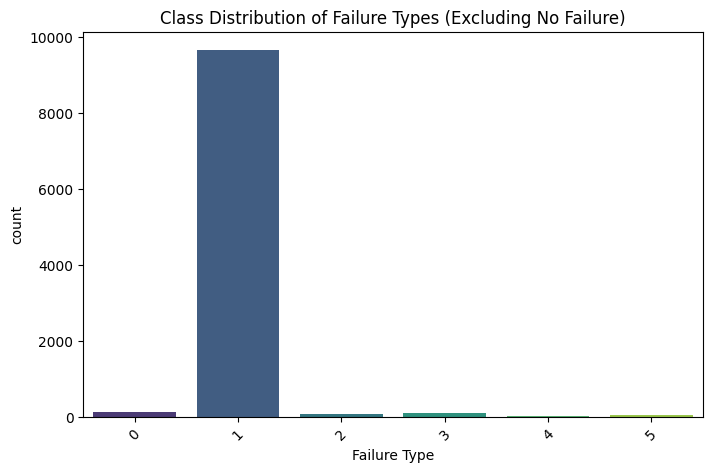

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'No Failure'
df_filtered = df[df['Failure Type'] != 'No Failure']

# Count failure types (excluding 'No Failure')
failure_counts = df_filtered['Failure Type'].value_counts()

# Print filtered failure counts
print(failure_counts)

# Plot failure distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=df_filtered['Failure Type'], palette='viridis')
plt.xticks(rotation=45)
plt.title('Class Distribution of Failure Types (Excluding No Failure)')
plt.show()


In [ ]:
# converting the categories to numbers in the failure types

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Failure Type'] = label_encoder.fit_transform(df['Failure Type'])

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print('class mapping: ', class_mapping)

print(df.info())


class mapping:  {'Heat Dissipation Failure': np.int64(0), 'No Failure': np.int64(1), 'Overstrain Failure': np.int64(2), 'Power Failure': np.int64(3), 'Random Failures': np.int64(4), 'Tool Wear Failure': np.int64(5)}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  int64  
dtypes: float64(3), int64(5)

Failure Type
Heat Dissipation Failure    112
Power Failure                95
Overstrain Failure           78
Tool Wear Failure            45
Random Failures              18
Name: count, dtype: int64


<ipython-input-11-3a32b9b33058>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_failures_only['Failure Type'] = df_failures_only['Failure Type'].map(reverse_mapping)
<ipython-input-11-3a32b9b33058>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_failures_only['Failure Type'], palette='viridis')


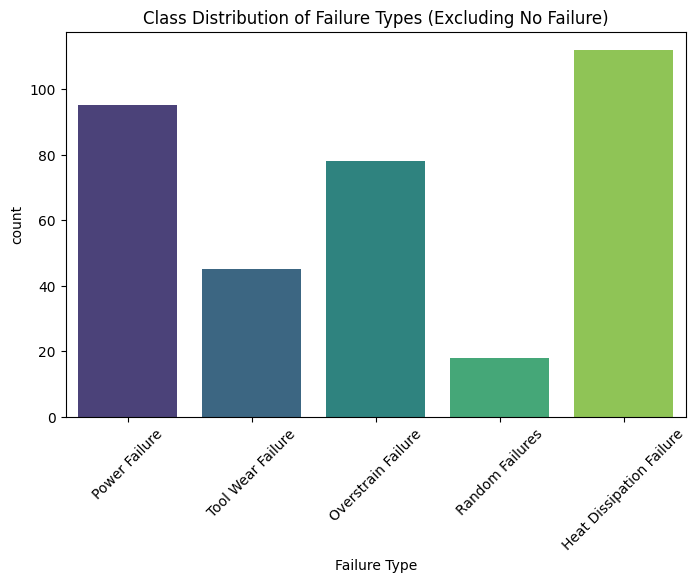

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude "No Failure" from the dataset before plotting
df_failures_only = df[df['Failure Type'] != class_mapping['No Failure']]  # Remove encoded "No Failure"

# Reverse mapping to restore original failure type names
reverse_mapping = {v: k for k, v in class_mapping.items()}  # Swap keys & values
df_failures_only['Failure Type'] = df_failures_only['Failure Type'].map(reverse_mapping)

# Count failure types
print(df_failures_only['Failure Type'].value_counts())

# Plot class distribution (excluding "No Failure")
plt.figure(figsize=(8,5))
sns.countplot(x=df_failures_only['Failure Type'], palette='viridis')
plt.xticks(rotation=45)
plt.title('Class Distribution of Failure Types (Excluding No Failure)')
plt.show()


In [ ]:
# now that the classes are numerated

# to have a better forecast , lets choose the relevant features
from sklearn.preprocessing import StandardScaler

features = ['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']
target = 'Failure Type'


x = df[features]
y = df[target]


# normalize the featers
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled = pd.DataFrame(x_scaled , columns=features)
x_scaled.head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430
3,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009
4,-0.902393,-0.879959,-0.729472,0.001313,-1.554588


In [ ]:
# lets train the data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

# Check dataset sizes
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)


Training Set: (8000, 5)
Testing Set: (2000, 5)


In [ ]:
# lets build the deep neural network

import torch
import torch.nn as nn
import torch.optim as optim

# converting features x and y to tensors
x_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

x_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

print("x_train shape:", x_train_tensor.shape)
print("y_train shape:", y_train_tensor.shape)

x_train shape: torch.Size([8000, 5])
y_train shape: torch.Size([8000])


In [ ]:
class MachineFailureClassifier(nn.Module):
  def __init__(self,input_size, num_classes):
    super(MachineFailureClassifier, self).__init__()
    self.fc1 = nn.Linear(input_size, 64)
    self.fc2 = nn.Linear(64,32)
    self.fc3 = nn.Linear(32, num_classes)
    self.relu = nn.ReLU()
    self.softmax = nn.Softmax(dim=1)

  def forward(self,x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
    return self.softmax(x)

input_size = X_train.shape[1] # number of features
num_classes = len(class_mapping)

model = MachineFailureClassifier(input_size, num_classes)

print(model)

MachineFailureClassifier(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=6, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.01)

In [ ]:
epochs = 100

for epoch in range(epochs):
  model.train()

  predictions = model(x_train_tensor)
  loss = criterion(predictions, y_train_tensor)

  # backward pass
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 10/100, Loss: 1.0943
Epoch 20/100, Loss: 1.0790
Epoch 30/100, Loss: 1.0790
Epoch 40/100, Loss: 1.0790
Epoch 50/100, Loss: 1.0790
Epoch 60/100, Loss: 1.0790
Epoch 70/100, Loss: 1.0790
Epoch 80/100, Loss: 1.0790
Epoch 90/100, Loss: 1.0790
Epoch 100/100, Loss: 1.0790


In [ ]:
# Set model to evaluation mode
model.eval()

# Disable gradient calculation (for efficiency)
with torch.no_grad():
    y_pred_classes = model(x_test_tensor)

# Convert predictions to class labels
y_pred_classes = torch.argmax(y_pred_classes, axis=1).numpy()
y_test_np = y_test_tensor.numpy()  # Convert actual labels to NumPy


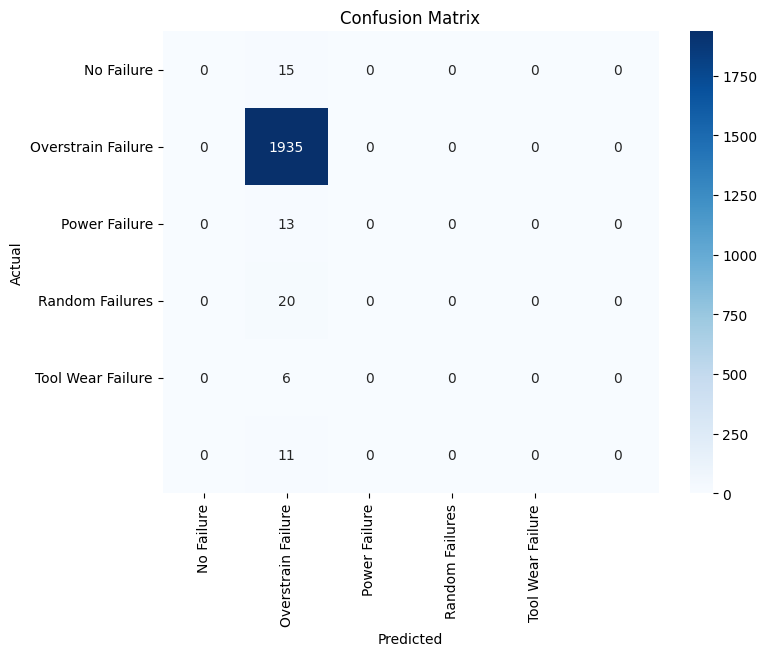

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test_np, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=list(class_mapping.keys())[1:], yticklabels=list(class_mapping.keys())[1:])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
